In [3]:
!pip install annoy

In [4]:
from annoy import AnnoyIndex
import numpy as np
import pandas as pd
import joblib
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [5]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [6]:
CNN = joblib.load("/content/gdrive/MyDrive/ml/restnet50Finetune/cnnRestnet50Finetune.sav")
restnet50 = joblib.load('/content/gdrive/MyDrive/ml/restnet50Finetune/restnet50Finetune.sav')
stdScaler = joblib.load('/content/gdrive/MyDrive/ml/restnet50Finetune/stdScaler.pkl')
mmScaler = joblib.load('/content/gdrive/MyDrive/ml/restnet50Finetune/minMaxScaler.pkl')

In [7]:
df = pd.read_csv("/content/gdrive/MyDrive/ml/restnet50Finetune/trainValiVectors.csv")
filenames = df["filename"].values
vectors = df.drop(columns=["filename"]).values

In [ ]:
vector_dim = vectors.shape[1]
ann_index = AnnoyIndex(vector_dim, metric='euclidean')

for i, v in enumerate(vectors):
    ann_index.add_item(i, v.tolist())

ann_index.build(1000)
ann_index.save("annoyRestnet50.ann")

True

In [9]:
datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

In [10]:
restnet50.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d            │ (None, 2048)           │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,587,712 (89.98 MB)

In [11]:
CNN.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 512)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,315,840 (5.02 MB)

 Trainable params: 1,313,792 (5.01 MB)

 Non-trainable params: 2,048 (8.00 KB)

In [12]:
def extract_feature(img_path):
    img = image.load_img(img_path, target_size=(224,224))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)

    features = restnet50.predict(x, verbose=0)
    features = features / np.linalg.norm(features, axis=1, keepdims=True)
    features = stdScaler.transform(features)
    features = CNN.predict(features, verbose=0)
    features = mmScaler.transform(features)
    return features.flatten()


In [13]:
def find_similar_images(img_path, top_k=10):
    query_vec = extract_feature(img_path)
    idxs = ann_index.get_nns_by_vector(query_vec, top_k, include_distances=True)
    results = [(filenames[i], d) for i, d in zip(idxs[0], idxs[1])]
    return results

In [14]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

pathh = '/content/gdrive/MyDrive/ml/train+vali'

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


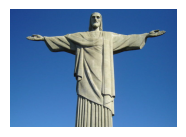

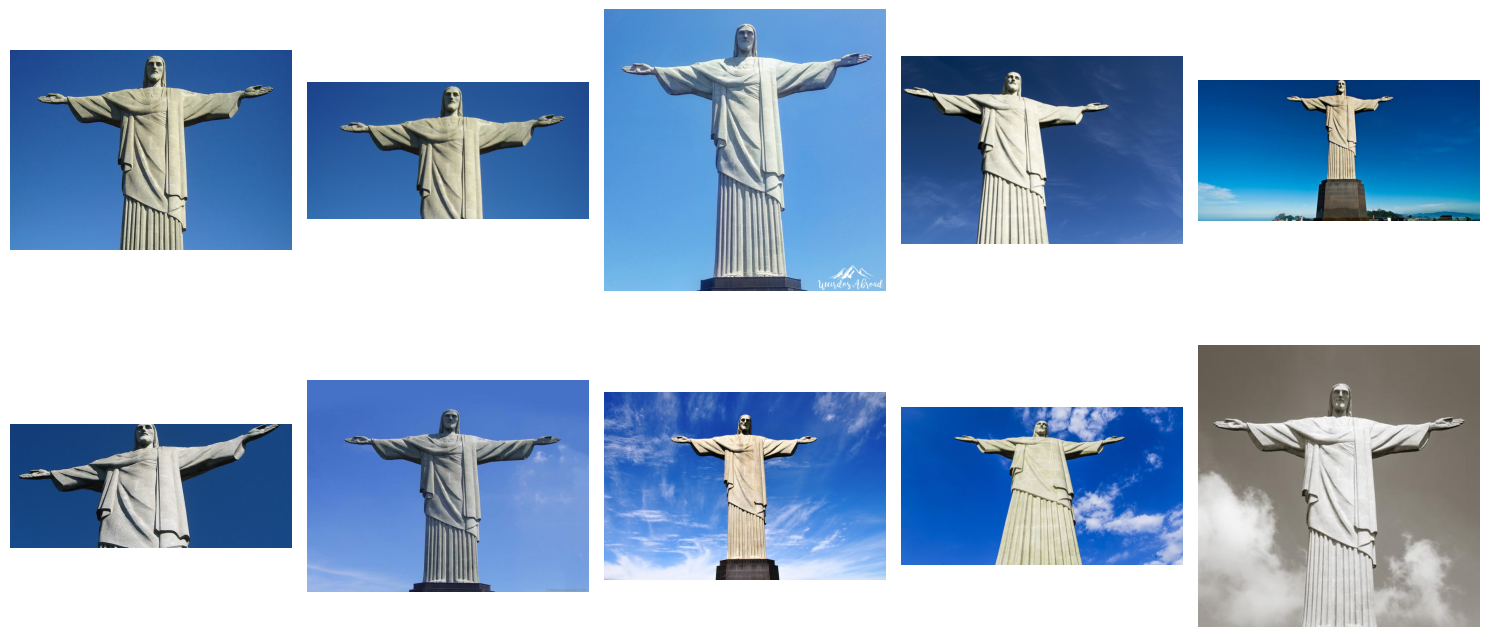

In [ ]:
queryImg = "90.jpg"
similar = find_similar_images(queryImg)

plt.figure(figsize=(15, 8))
plt.subplot(2, 6, 1)
img = mpimg.imread(queryImg)
plt.imshow(img)
plt.axis('off')
plt.show()

plt.figure(figsize=(15, 8))
for i, (fname, dist) in enumerate(similar[:10], start=1):
    plt.subplot(2, 5, i)
    similar_image_full_path = os.path.join(pathh, fname)
    img = mpimg.imread(similar_image_full_path)
    plt.imshow(img)
    plt.axis('off')

plt.tight_layout()
plt.show()